
# Global Economy Indicators - Descriptive Analysis

This notebook performs descriptive statistical analysis on the prepared Global Economy Indicators dataset. The steps include:

1. Loading the prepared dataset
2. Descriptive statistics for GDP, GNI, Population
3. Frequency distribution for Industry Sectors
4. Visualizations (Histograms and Boxplots)
5. Correlation matrix and heatmap for key variables



## Step 1: Load the prepared dataset


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (adjust path if needed)
file_path = 'Prepared_Global_Economy_Indicators.csv'
df = pd.read_csv(file_path)

df.head()


,Country,Population,Per capita GNI,Gross National Income(GNI) in USD,Gross Domestic Product (GDP),"Agriculture, hunting, forestry, fishing (ISIC A-B) (%)",Manufacturing (ISIC D) (%),"Mining, Manufacturing, Utilities (ISIC C-E) (%)",Other Activities (ISIC J-P) (%),"Transport, storage and communication (ISIC I) (%)","Wholesale, retail trade, restaurants and hotels (ISIC G-H) (%)",Construction (ISIC F) (%)
0,Afghanistan,37834278.6,490.2,1.848147e+10,1.826043e+10,26.647550,6.607820,10.311960,35.434846,8.849393,10.947185,3.026326
1,Albania,2870362.0,5312.8,1.524521e+10,1.539398e+10,18.508810,6.166922,11.811473,28.619393,6.120102,13.295115,9.055507
2,Algeria,42679711.2,3801.6,1.620000e+11,1.652000e+11,12.342520,4.393247,25.808599,22.627621,10.407717,13.571408,11.468404
3,Andorra,76385.4,40827.8,3.117875e+09,3.117875e+09,0.543426,3.769346,4.886301,51.489581,5.258084,21.697452,6.753237
4,Angola,32353601.8,2551.6,8.161615e+10,8.629821e+10,9.516977,6.488813,35.849597,20.216044,3.152782,20.462605,10.503025



## Step 2: Descriptive statistics for GDP, GNI, Population
We calculate Mean, Median, Std Dev, Min, Max for each indicator.


In [2]:

# Select key indicators
indicators = ['Gross Domestic Product (GDP)', 'Gross National Income(GNI) in USD', 'Population']

# Compute descriptive statistics
stats = df[indicators].agg(['mean', 'median', 'std', 'min', 'max'])
stats


,Gross Domestic Product (GDP),Gross National Income(GNI) in USD,Population
mean,4.098835e+11,4.099532e+11,3.648078e+07
median,2.504182e+10,2.408757e+10,6.613748e+06
std,1.846124e+12,1.866675e+12,1.410414e+08
min,5.188266e+07,6.704114e+07,4.496000e+03
max,2.116000e+13,2.154000e+13,1.420007e+09


## Step 2.5: Visualization of Skewness — Non-Zoomed vs. Zoomed KDE Plots

To better understand the distribution characteristics of three key economic indicators—**GDP**, **GNI**, and **Population**—we use **Kernel Density Estimation (KDE)** plots. These visualizations help highlight the central tendencies (mean, median, mode) and detect skewness in the data.

### What These Graphs Show:
- **Full Range KDE** (Left): Shows the entire dataset, including extreme values. This is useful to identify outliers and the general shape.
- **Zoomed KDE (95th Percentile)** (Right): Focuses on the majority of the data (excluding the top 5% of values). This gives a clearer picture of where most countries lie.

**Line Indicators:**
- 🔴 **Red Dashed Line**: Mean — the average value.
- 🟢 **Green Solid Line**: Median — the middle value.
- 🔵 **Blue Dotted Line**: Mode — the most frequent value.

**Why This Matters:**
These plots visually reveal **right-skewness**, which is common in economic data. A few countries with very high GDP, GNI, or population pull the mean far above the median and mode. Understanding this helps us choose appropriate statistical methods and visual tools for comparisons.

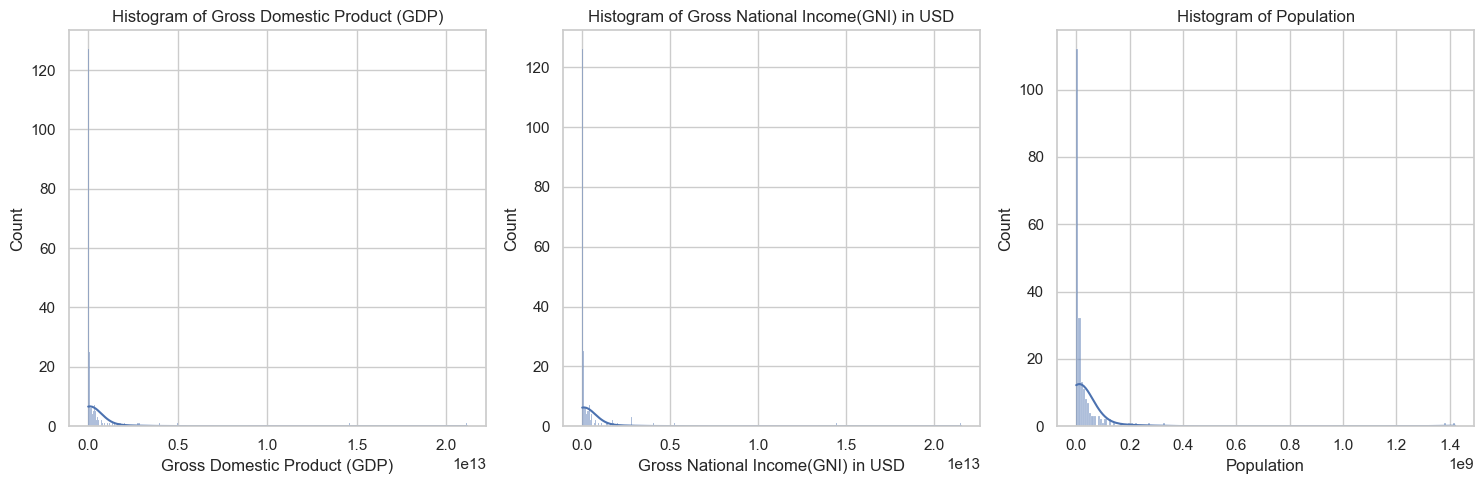

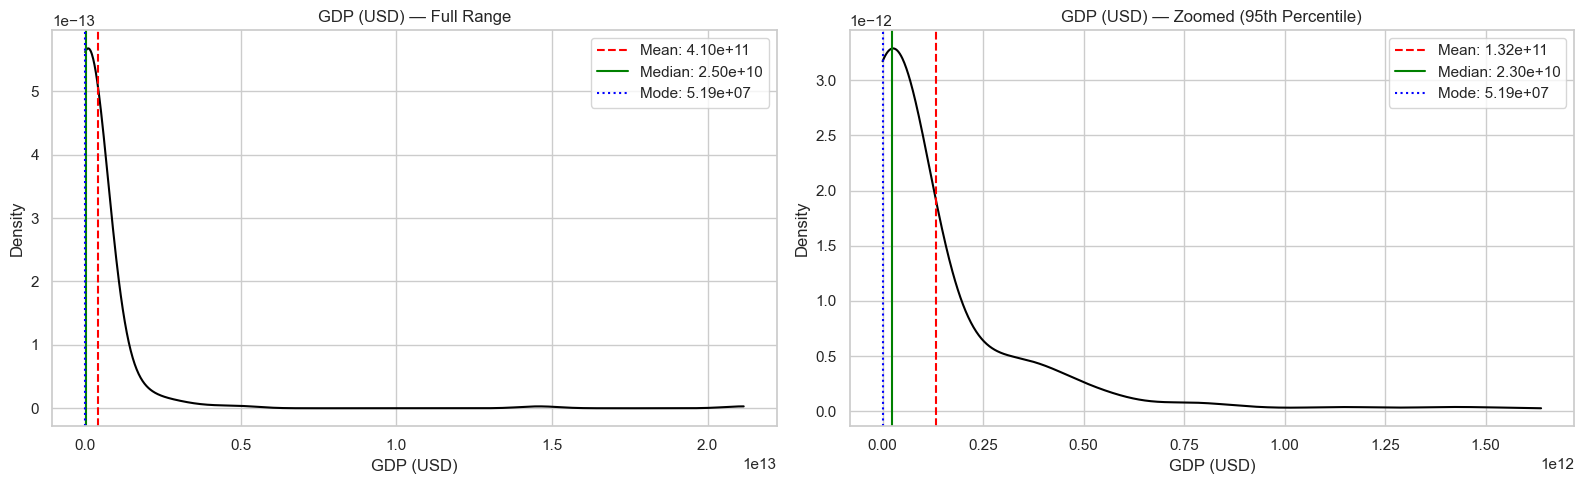

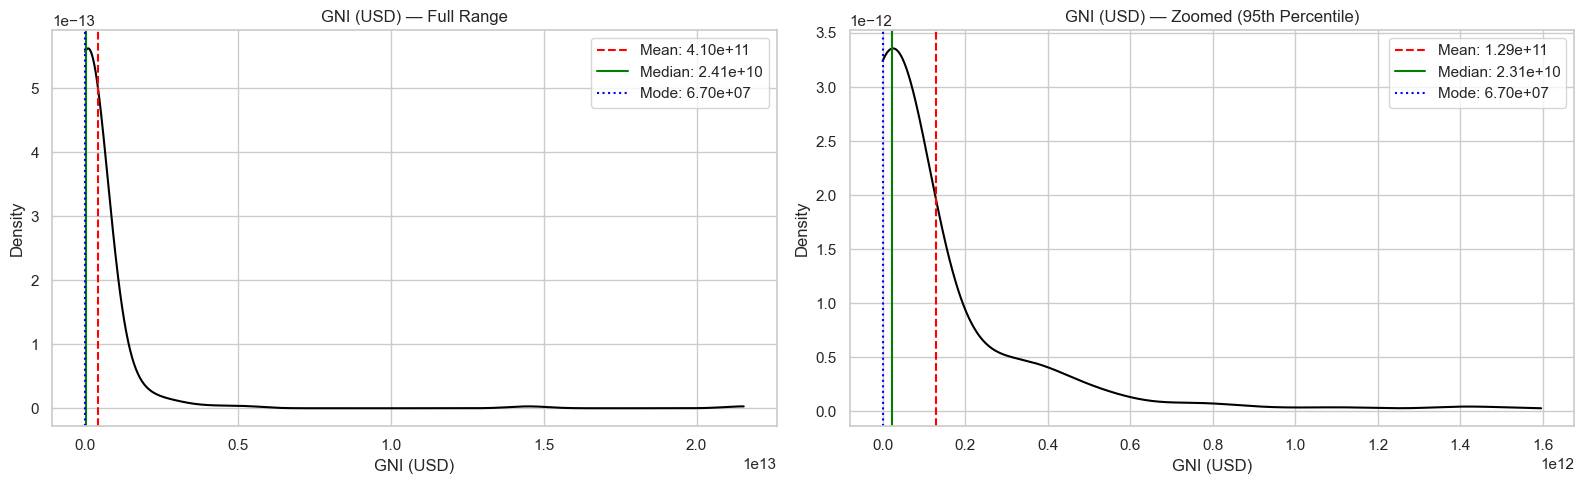

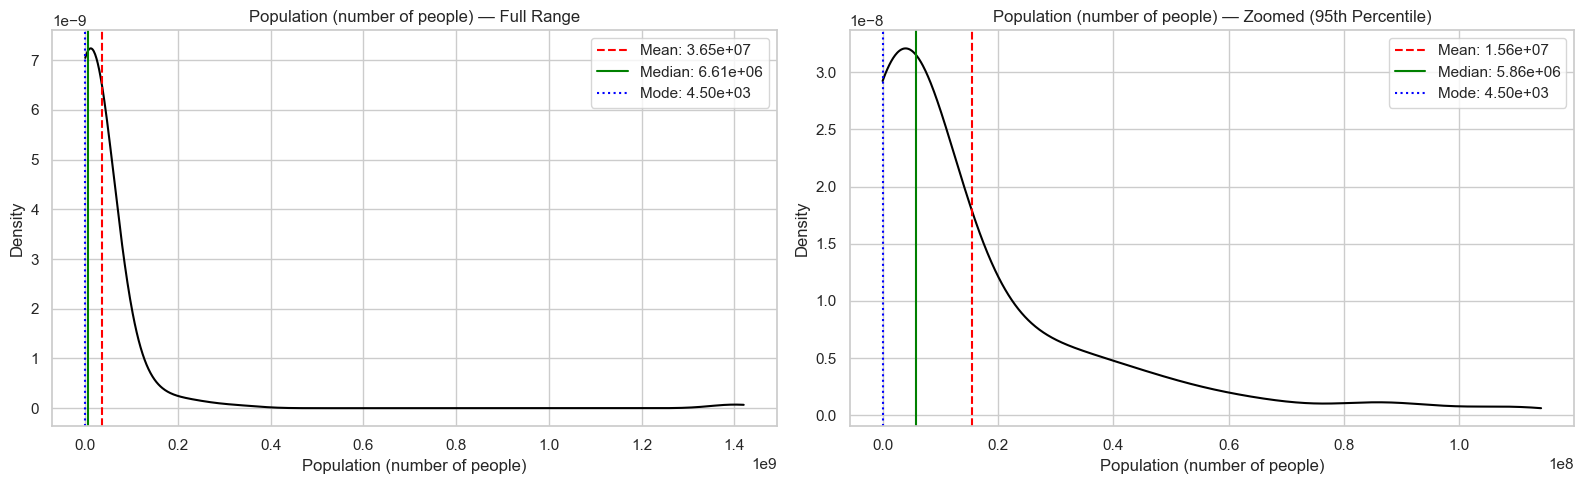

In [15]:

# Set style for plots
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

for i, col in enumerate(indicators):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


# Step 2.5: Visualization of Skewness — Non-Zoomed vs. Zoomed KDE Plots

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

indicators_with_units = [
    ('Gross Domestic Product (GDP)', 'GDP (USD)'),
    ('Gross National Income(GNI) in USD', 'GNI (USD)'),
    ('Population', 'Population (number of people)')
]

for col, label_name in indicators_with_units:
    # Clean and convert to float
    data = pd.to_numeric(df[col], errors='coerce').dropna().astype('float64')
    data = data[np.isfinite(data)]

    # Full Range KDE
    kde_full = gaussian_kde(data)
    x_vals_full = np.linspace(data.min(), data.max(), 1000)
    y_vals_full = kde_full(x_vals_full)

    # Zoomed KDE (up to 95th percentile)
    data_zoomed = data[data <= np.percentile(data, 95)]
    kde_zoom = gaussian_kde(data_zoomed)
    x_vals_zoom = np.linspace(data_zoomed.min(), data_zoomed.max(), 1000)
    y_vals_zoom = kde_zoom(x_vals_zoom)

    # Compute statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    mode_val = data.mode().iloc[0]

    # Plot both
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    # Full Range
    axs[0].plot(x_vals_full, y_vals_full, color='black')
    axs[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.2e}')
    axs[0].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:,.2e}')
    axs[0].axvline(mode_val, color='blue', linestyle=':', label=f'Mode: {mode_val:,.2e}')
    axs[0].set_title(f'{label_name} — Full Range')
    axs[0].set_xlabel(label_name)
    axs[0].set_ylabel("Density")
    axs[0].legend()

    # Zoomed
    mean_zoom = np.mean(data_zoomed)
    median_zoom = np.median(data_zoomed)
    mode_zoom = data_zoomed.mode().iloc[0]

    axs[1].plot(x_vals_zoom, y_vals_zoom, color='black')
    axs[1].axvline(mean_zoom, color='red', linestyle='--', label=f'Mean: {mean_zoom:,.2e}')
    axs[1].axvline(median_zoom, color='green', linestyle='-', label=f'Median: {median_zoom:,.2e}')
    axs[1].axvline(mode_zoom, color='blue', linestyle=':', label=f'Mode: {mode_zoom:,.2e}')
    axs[1].set_title(f'{label_name} — Zoomed (95th Percentile)')
    axs[1].set_xlabel(label_name)
    axs[1].set_ylabel("Density")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


## Step 3: Frequency distribution for Industry Sectors (% of GDP)


In [5]:

# Select industry sector columns
industry_columns = [col for col in df.columns if '(%)' in col]

# Compute descriptive stats for industry sectors
industry_stats = df[industry_columns].agg(['mean', 'median', 'std', 'min', 'max'])
industry_stats


,"Agriculture, hunting, forestry, fishing (ISIC A-B) (%)",Manufacturing (ISIC D) (%),"Mining, Manufacturing, Utilities (ISIC C-E) (%)",Other Activities (ISIC J-P) (%),"Transport, storage and communication (ISIC I) (%)","Wholesale, retail trade, restaurants and hotels (ISIC G-H) (%)",Construction (ISIC F) (%)
mean,10.460170,11.220247,19.119351,34.366930,8.141897,14.675520,5.854738
median,6.567375,10.587410,18.303625,32.731779,8.097049,13.718911,5.385196
std,11.129656,7.362148,11.188207,11.578895,2.871391,5.526428,3.130414
min,0.015930,0.451491,1.354848,6.575506,1.361214,0.338614,0.818053
max,67.253965,47.881708,58.999570,75.525905,22.550599,34.393032,18.040891


## Step 3.5: KDE Distribution Plots for Industry Sectors (% of GDP)

This section provides kernel density plots for each industry sector as a percentage of GDP. Each graph includes both the full distribution and a zoomed view (up to the 95th percentile) to better illustrate the typical country-level contribution of each sector.

**Line Indicators:**
- 🔴 Mean
- 🟢 Median
- 🔵 Mode

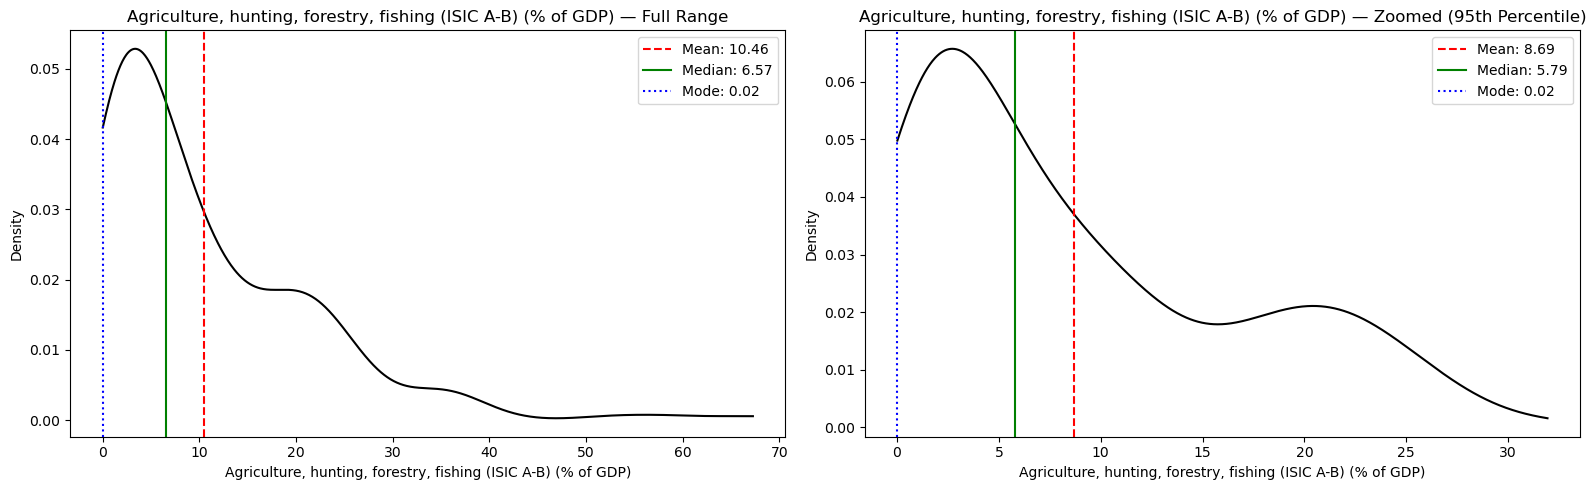

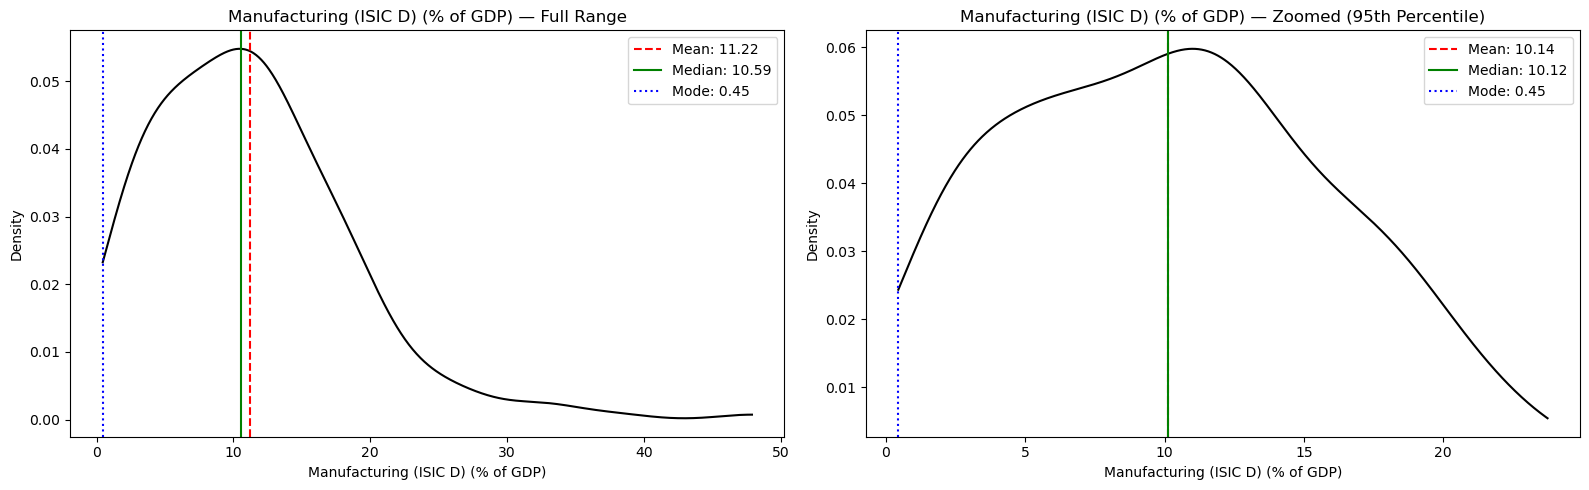

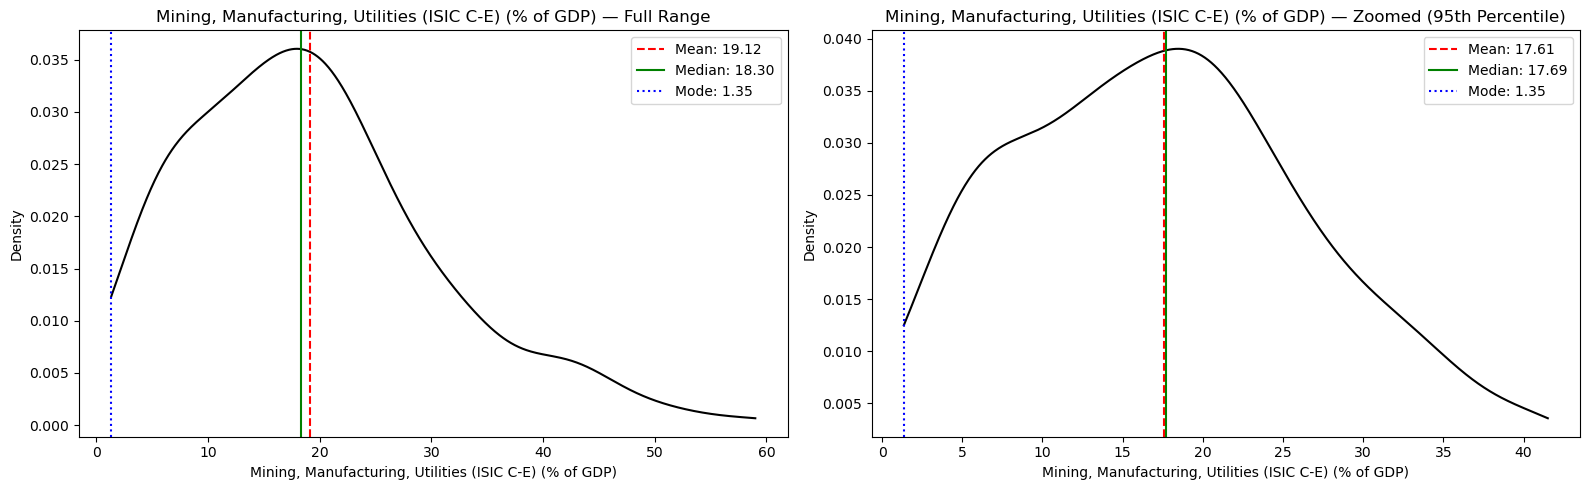

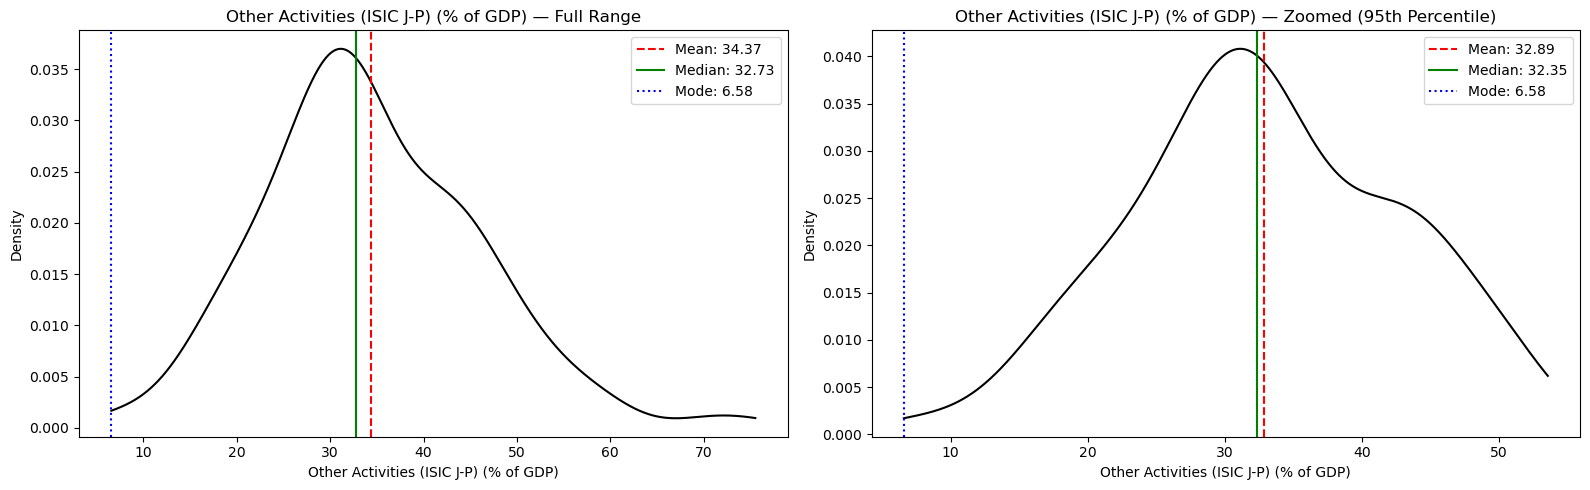

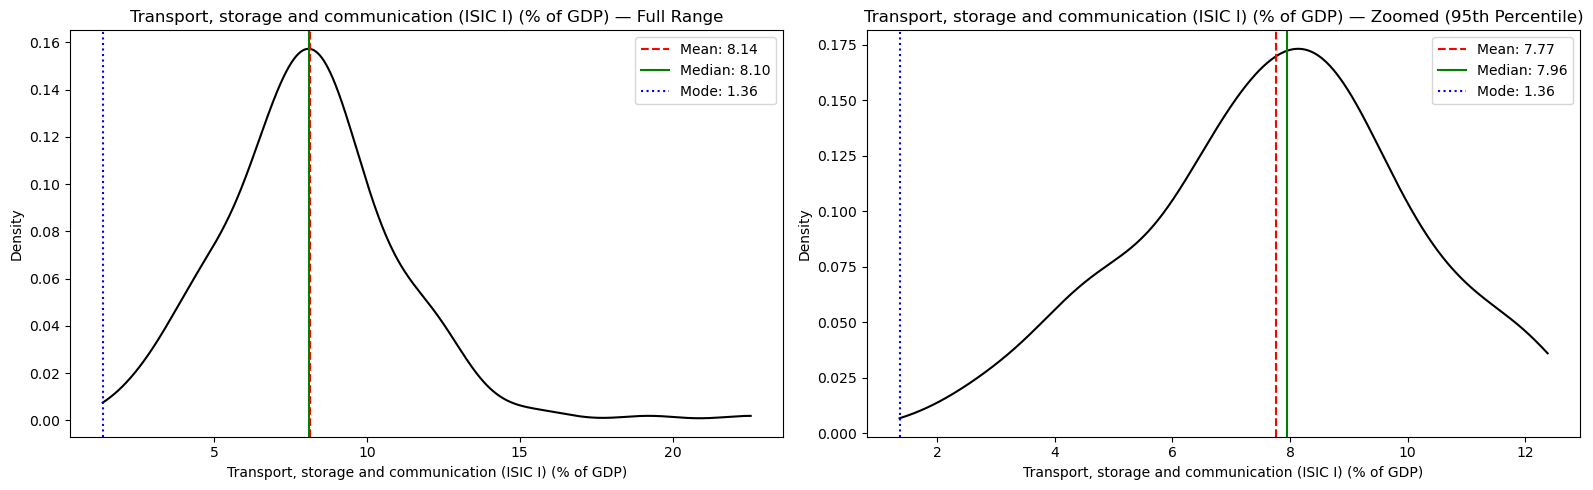

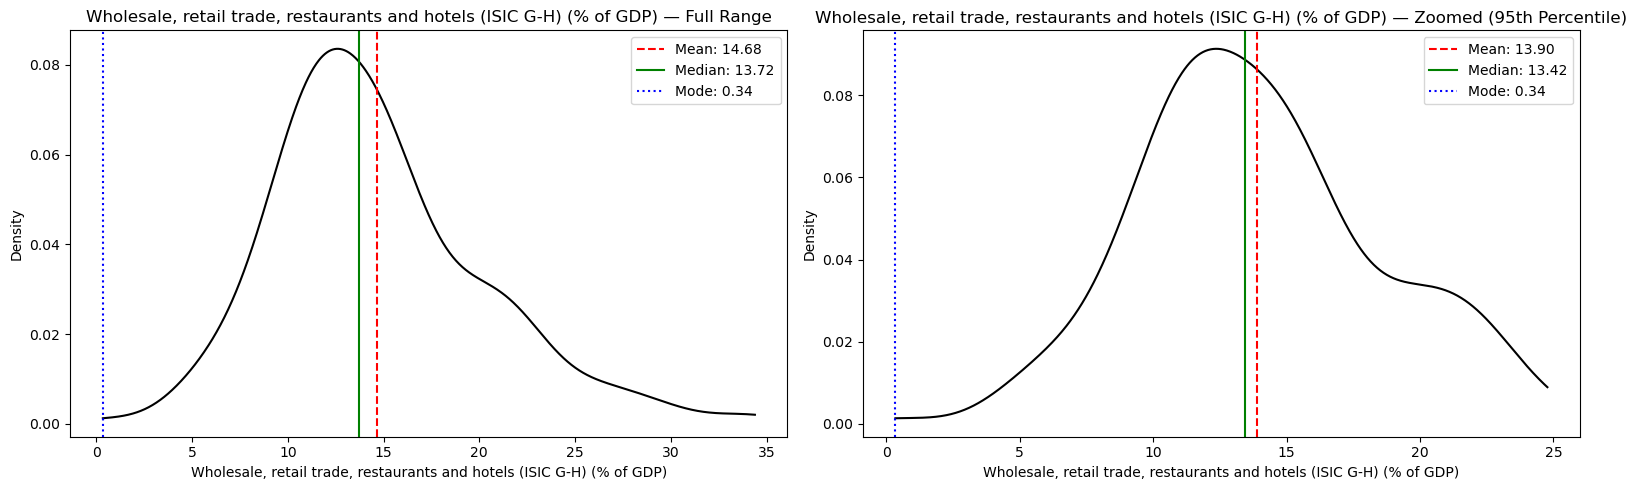

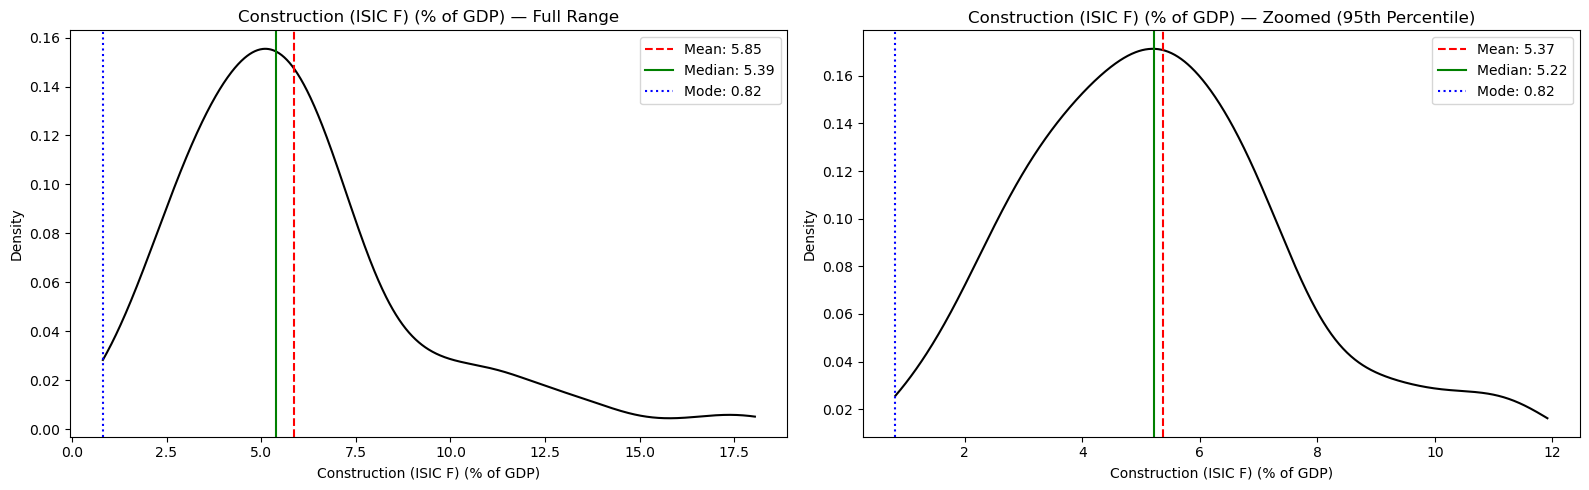

In [6]:
# Step 3.5: KDE Distribution Plots for Industry Sectors (% of GDP)

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# Identify sector columns (% of GDP)
sector_columns = [col for col in df.columns if '(%)' in col]

for col in sector_columns:
    label_name = col.replace("(%)", "").strip() + " (% of GDP)"

    # Clean and convert to float
    data = pd.to_numeric(df[col], errors='coerce').dropna().astype('float64')
    data = data[np.isfinite(data)]

    # Full Range KDE
    kde_full = gaussian_kde(data)
    x_vals_full = np.linspace(data.min(), data.max(), 1000)
    y_vals_full = kde_full(x_vals_full)

    # Zoomed KDE (up to 95th percentile)
    data_zoomed = data[data <= np.percentile(data, 95)]
    kde_zoom = gaussian_kde(data_zoomed)
    x_vals_zoom = np.linspace(data_zoomed.min(), data_zoomed.max(), 1000)
    y_vals_zoom = kde_zoom(x_vals_zoom)

    # Compute statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    mode_val = data.mode().iloc[0]

    # Plot both
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    # Full Range
    axs[0].plot(x_vals_full, y_vals_full, color='black')
    axs[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axs[0].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axs[0].axvline(mode_val, color='blue', linestyle=':', label=f'Mode: {mode_val:.2f}')
    axs[0].set_title(f'{label_name} — Full Range')
    axs[0].set_xlabel(label_name)
    axs[0].set_ylabel("Density")
    axs[0].legend()

    # Zoomed
    mean_zoom = np.mean(data_zoomed)
    median_zoom = np.median(data_zoomed)
    mode_zoom = data_zoomed.mode().iloc[0]

    axs[1].plot(x_vals_zoom, y_vals_zoom, color='black')
    axs[1].axvline(mean_zoom, color='red', linestyle='--', label=f'Mean: {mean_zoom:.2f}')
    axs[1].axvline(median_zoom, color='green', linestyle='-', label=f'Median: {median_zoom:.2f}')
    axs[1].axvline(mode_zoom, color='blue', linestyle=':', label=f'Mode: {mode_zoom:.2f}')
    axs[1].set_title(f'{label_name} — Zoomed (95th Percentile)')
    axs[1].set_xlabel(label_name)
    axs[1].set_ylabel("Density")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

### Step 3.6 (Updated): Five-Number Summary Split by Indicator Type

To improve clarity, the five-number summary has been split into two tables:

**1. Macro Indicators**: GDP, GNI, and Population
**2. Sectoral Indicators**: Percentage contribution to GDP from various industries

Each table includes:
- **Minimum**
- **Q1 (25th percentile)**
- **Median**
- **Q3 (75th percentile)**
- **Maximum**

In [7]:
# Recompute 5-number summary and split into macro and sectoral tables

# Columns to include
full_columns = [col for col in df.columns if '(%)' in col] + [
    'Gross Domestic Product (GDP)',
    'Gross National Income(GNI) in USD',
    'Population'
]

# Compute 5-number summary
summary = df[full_columns].agg([
    'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
])
summary.index = ['Minimum', 'Q1 (25th percentile)', 'Median', 'Q3 (75th percentile)', 'Maximum']
summary = summary.T

# Reorder by original column order
ordered_cols = [col for col in df.columns if col in summary.index]
summary = summary.loc[ordered_cols]

# Split into macro and sectoral
macro_cols = [
    'Gross Domestic Product (GDP)',
    'Gross National Income(GNI) in USD',
    'Population'
]
sector_cols = [col for col in summary.index if col not in macro_cols]

macro_summary = summary.loc[macro_cols]
sector_summary = summary.loc[sector_cols]

# Display both tables
print("Macro Indicators Summary (GDP, GNI, Population)")
display(macro_summary.reset_index().rename(columns={'index': 'Indicator'}))

print("\nSectoral Indicators Summary (% of GDP)")
display(sector_summary.reset_index().rename(columns={'index': 'Indicator'}))

Macro Indicators Summary (GDP, GNI, Population)


,Indicator,Minimum,Q1 (25th percentile),Median,Q3 (75th percentile),Maximum
0,Gross Domestic Product (GDP),51882655.6,5.871359e+09,2.504182e+10,1.712000e+11,2.116000e+13
1,Gross National Income(GNI) in USD,67041142.4,6.115043e+09,2.408757e+10,1.630500e+11,2.154000e+13
2,Population,4496.0,1.146510e+06,6.613748e+06,2.548779e+07,1.420007e+09



Sectoral Indicators Summary (% of GDP)


,Indicator,Minimum,Q1 (25th percentile),Median,Q3 (75th percentile),Maximum
0,"Agriculture, hunting, forestry, fishing (ISIC ...",0.015930,2.118189,6.567375,16.929599,67.253965
1,Manufacturing (ISIC D) (%),0.451491,5.891233,10.587410,14.989239,47.881708
2,"Mining, Manufacturing, Utilities (ISIC C-E) (%)",1.354848,10.866641,18.303625,24.920154,58.999570
3,Other Activities (ISIC J-P) (%),6.575506,27.429301,32.731779,42.220669,75.525905
4,"Transport, storage and communication (ISIC I) (%)",1.361214,6.502829,8.097049,9.619573,22.550599
5,"Wholesale, retail trade, restaurants and hotel...",0.338614,11.071629,13.718911,17.135997,34.393032
6,Construction (ISIC F) (%),0.818053,3.822559,5.385196,6.982581,18.040891


## Step 3.7: Box Plot Visualizations for Economic Indicators

This section includes both non-zoomed and zoomed box plots for:
- **GDP and GNI** (with 90th percentile zoom)
- **Population** (90th and 95th percentile zoom)
- **Sectoral Indicators** (% of GDP)

These plots help visualize the spread and detect outliers across macroeconomic and sector-specific indicators.

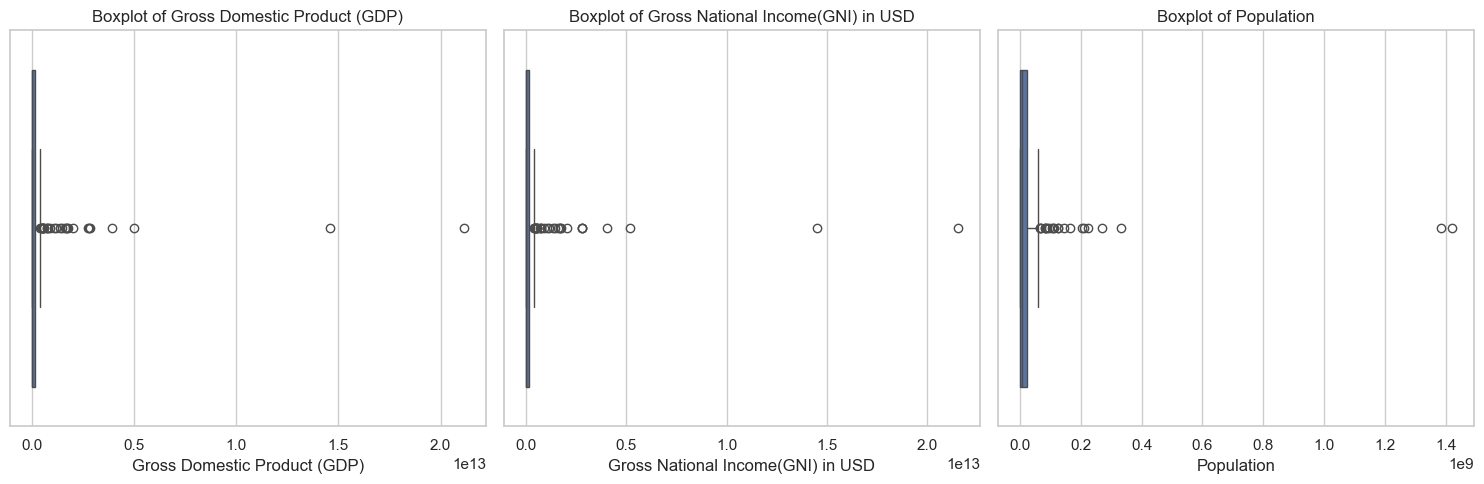

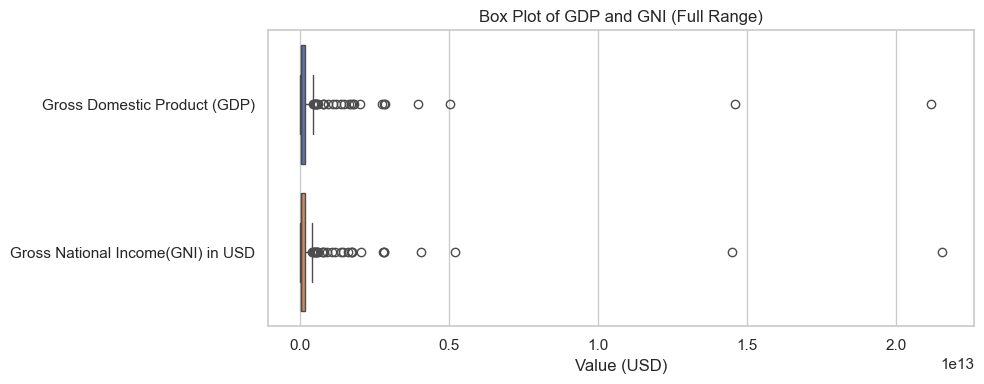

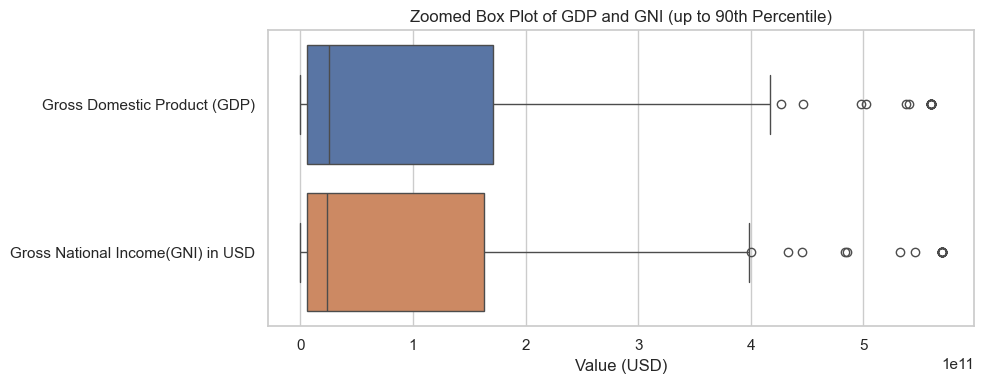

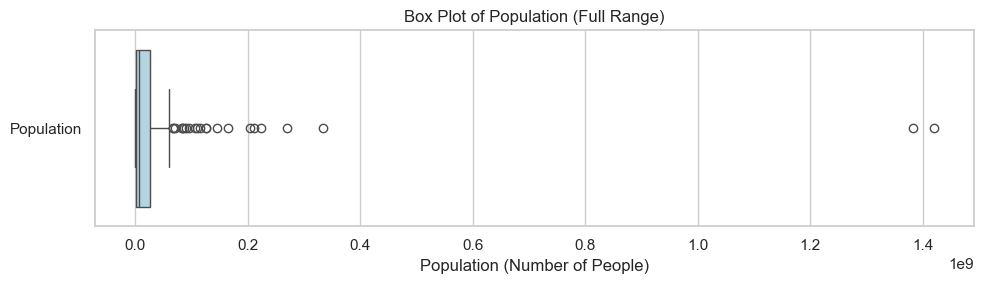

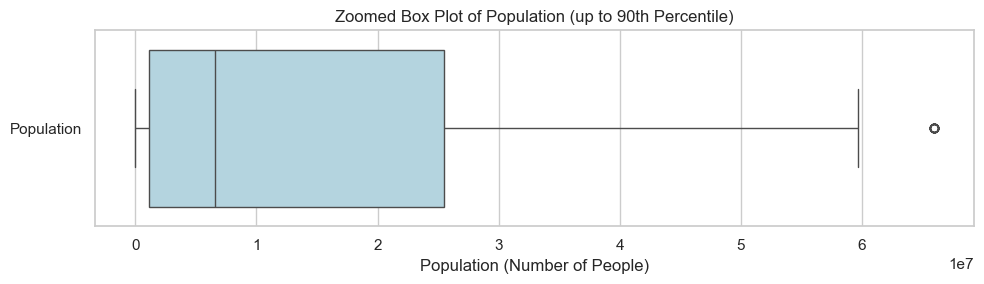

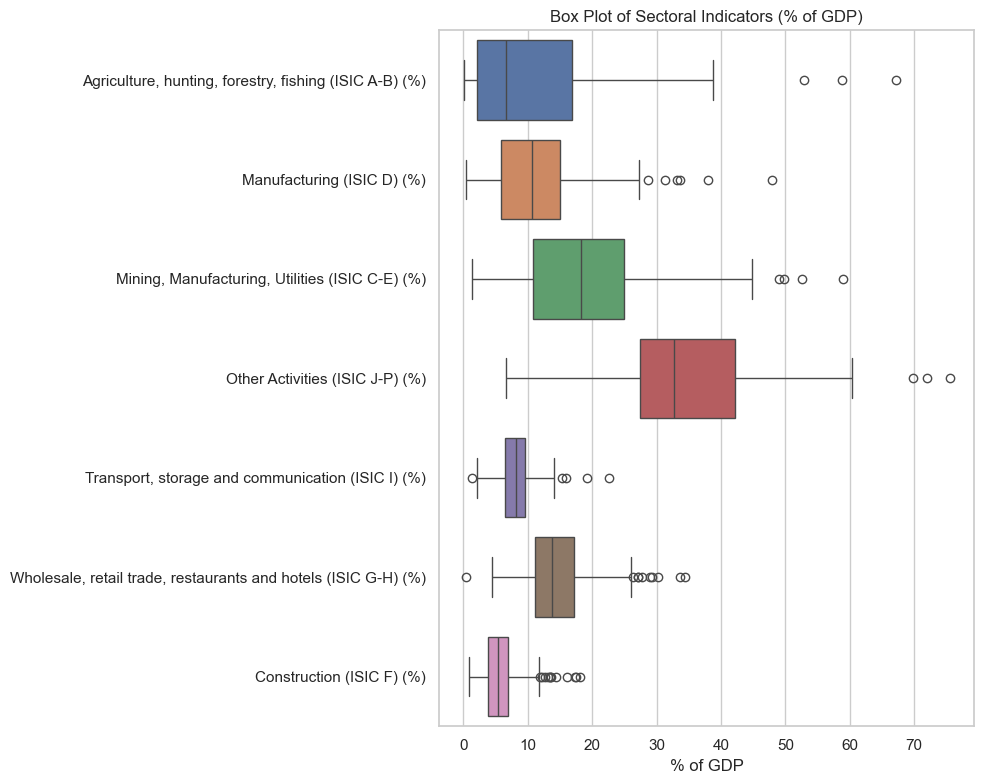

In [18]:

# Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(indicators):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()
print('\n\n\n')


import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
macro_cols = [
    'Gross Domestic Product (GDP)',
    'Gross National Income(GNI) in USD',
    'Population'
]
sector_cols = [col for col in df.columns if '(%)' in col]

macro_data = df[macro_cols].apply(pd.to_numeric, errors='coerce')
sector_data = df[sector_cols].apply(pd.to_numeric, errors='coerce')

# GDP & GNI: Non-Zoomed
plt.figure(figsize=(10, 4))
sns.boxplot(data=macro_data[['Gross Domestic Product (GDP)', 'Gross National Income(GNI) in USD']], orient='h')
plt.title("Box Plot of GDP and GNI (Full Range)")
plt.xlabel("Value (USD)")
plt.tight_layout()
plt.show()

# GDP & GNI: Zoomed (90th percentile)
gdp_gni_clipped = macro_data[['Gross Domestic Product (GDP)', 'Gross National Income(GNI) in USD']].copy()
for col in gdp_gni_clipped.columns:
    gdp_gni_clipped[col] = gdp_gni_clipped[col].clip(upper=gdp_gni_clipped[col].quantile(0.90))
plt.figure(figsize=(10, 4))
sns.boxplot(data=gdp_gni_clipped, orient='h')
plt.title("Zoomed Box Plot of GDP and GNI (up to 90th Percentile)")
plt.xlabel("Value (USD)")
plt.tight_layout()
plt.show()

# Population: Non-Zoomed
plt.figure(figsize=(10, 3))
sns.boxplot(data=macro_data[['Population']], orient='h', color='lightblue')
plt.title("Box Plot of Population (Full Range)")
plt.xlabel("Population (Number of People)")
plt.tight_layout()
plt.show()

# Population: Zoomed (90th Percentile)
pop_zoom_90 = macro_data[['Population']].copy()
pop_zoom_90['Population'] = pop_zoom_90['Population'].clip(upper=pop_zoom_90['Population'].quantile(0.90))
plt.figure(figsize=(10, 3))
sns.boxplot(data=pop_zoom_90, orient='h', color='lightblue')
plt.title("Zoomed Box Plot of Population (up to 90th Percentile)")
plt.xlabel("Population (Number of People)")
plt.tight_layout()
plt.show()

# Sectoral Indicators: Box Plot
plt.figure(figsize=(10, 8))
sns.boxplot(data=sector_data, orient='h')
plt.title("Box Plot of Sectoral Indicators (% of GDP)")
plt.xlabel("% of GDP")
plt.tight_layout()
plt.show()

### 📦 Explanation: Box Plots and Outlier Annotations

**Box plots** are used to summarize the distribution of numeric variables. Each box plot shows:

- **Median** (central line in the box)
- **Interquartile Range (IQR)**: The box itself shows Q1 to Q3
- **Whiskers**: Extend up to 1.5×IQR from Q1 and Q3
- **Outliers**: Points beyond the whiskers (annotated in red)

These annotated box plots help identify extreme values and potential anomalies in:
- **Macroeconomic indicators** like GDP, GNI, and Population
- **Sectoral contributions** to GDP

Zoomed versions (up to the 90th percentile) enhance visibility of typical value ranges while reducing distortion from extreme outliers.

## Step 3.8: Annotated Box Plots for Outlier Detection

This section includes annotated box plots highlighting **outliers** for:
- **GDP and GNI** (zoomed to 90th percentile)
- **Population** (zoomed to 90th percentile)
- **Sectoral Indicators** (% of GDP)

Red labels represent values beyond the typical interquartile range (IQR). These are useful for detecting extreme variations across countries.

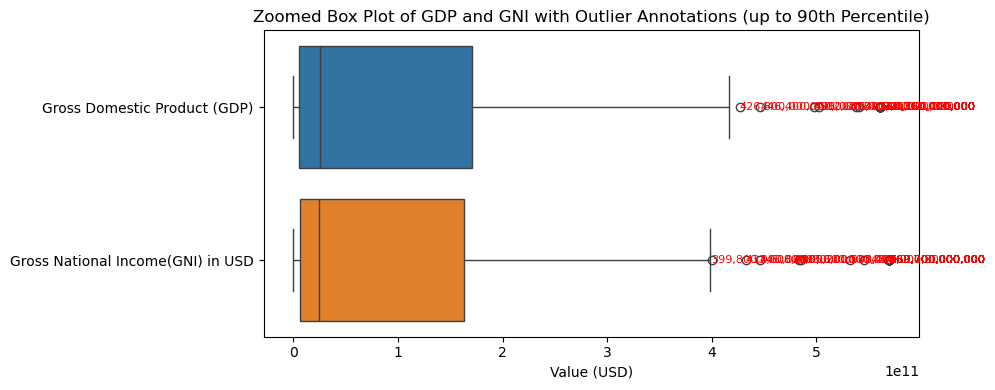

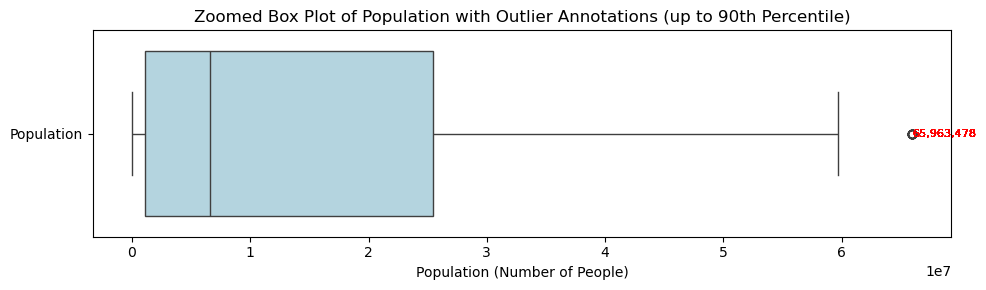

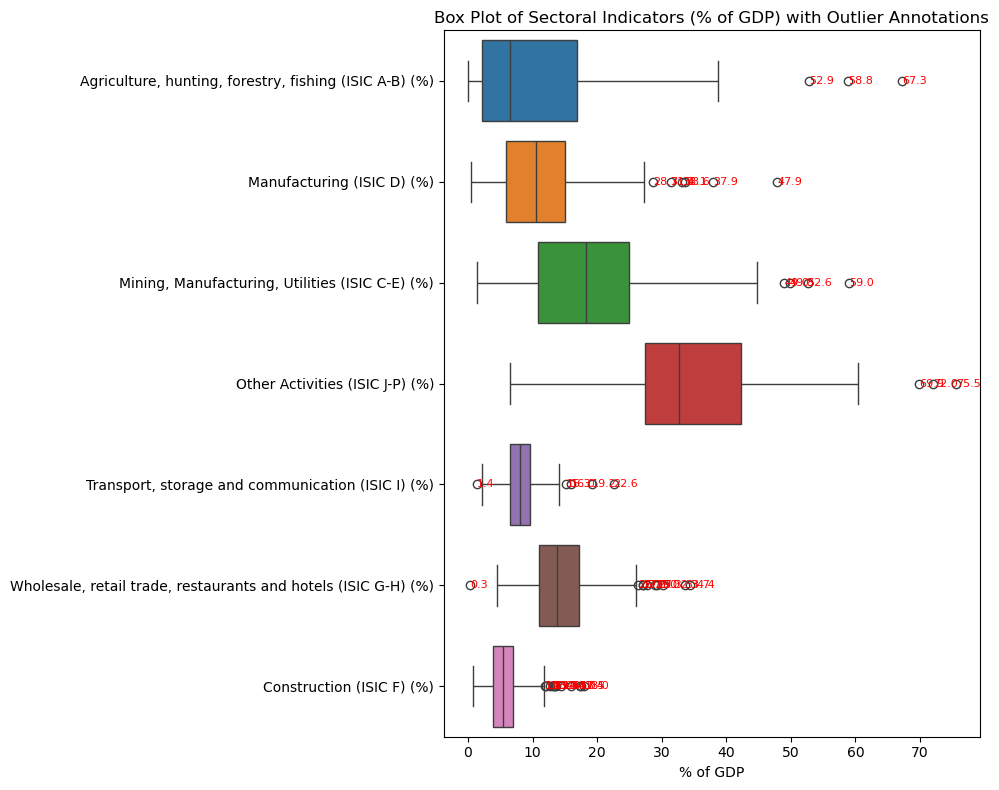

In [9]:
# Annotated Box Plots for GDP, GNI, Population, and Sectoral Indicators

import matplotlib.pyplot as plt
import seaborn as sns

# Prepare GDP & GNI clipped at 90th percentile
gdp_gni = df[['Gross Domestic Product (GDP)', 'Gross National Income(GNI) in USD']].apply(pd.to_numeric, errors='coerce')
gdp_gni_clipped = gdp_gni.copy()
for col in gdp_gni_clipped.columns:
    upper = gdp_gni_clipped[col].quantile(0.90)
    gdp_gni_clipped[col] = gdp_gni_clipped[col].clip(upper=upper)

# Prepare Population clipped at 90th percentile
pop_zoom_90 = df[['Population']].apply(pd.to_numeric, errors='coerce')
pop_zoom_90['Population'] = pop_zoom_90['Population'].clip(upper=pop_zoom_90['Population'].quantile(0.90))

# Prepare Sectoral data
sector_data = df[[col for col in df.columns if '(%)' in col]].apply(pd.to_numeric, errors='coerce')

# GDP & GNI Plot
plt.figure(figsize=(10, 4))
ax = sns.boxplot(data=gdp_gni_clipped, orient='h')
plt.title("Zoomed Box Plot of GDP and GNI with Outlier Annotations (up to 90th Percentile)")
plt.xlabel("Value (USD)")
for idx, col in enumerate(gdp_gni_clipped.columns):
    q1 = gdp_gni_clipped[col].quantile(0.25)
    q3 = gdp_gni_clipped[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outliers = gdp_gni_clipped[(gdp_gni_clipped[col] < lb) | (gdp_gni_clipped[col] > ub)][col]
    for val in outliers:
        ax.text(val, idx, f"{val:,.0f}", color='red', fontsize=8, va='center')
plt.tight_layout()
plt.show()

# Population Plot
plt.figure(figsize=(10, 3))
ax = sns.boxplot(data=pop_zoom_90, orient='h', color='lightblue')
plt.title("Zoomed Box Plot of Population with Outlier Annotations (up to 90th Percentile)")
plt.xlabel("Population (Number of People)")
q1 = pop_zoom_90['Population'].quantile(0.25)
q3 = pop_zoom_90['Population'].quantile(0.75)
iqr = q3 - q1
lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr
outliers = pop_zoom_90[(pop_zoom_90['Population'] < lb) | (pop_zoom_90['Population'] > ub)]['Population']
for val in outliers:
    ax.text(val, 0, f"{val:,.0f}", color='red', fontsize=8, va='center')
plt.tight_layout()
plt.show()

# Sectoral Indicators Plot
plt.figure(figsize=(10, 8))
ax = sns.boxplot(data=sector_data, orient='h')
plt.title("Box Plot of Sectoral Indicators (% of GDP) with Outlier Annotations")
plt.xlabel("% of GDP")
for idx, col in enumerate(sector_data.columns):
    q1 = sector_data[col].quantile(0.25)
    q3 = sector_data[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outliers = sector_data[(sector_data[col] < lb) | (sector_data[col] > ub)][col]
    for val in outliers:
        ax.text(val, idx, f"{val:.1f}", color='red', fontsize=8, va='center')
plt.tight_layout()
plt.show()


## Step 5: Correlation Matrix and Heatmap
We calculate the correlation between GDP, GNI and Population.


In [12]:

# Compute correlation matrix
corr = df[indicators].corr()
corr


,Gross Domestic Product (GDP),Gross National Income(GNI) in USD,Population
Gross Domestic Product (GDP),1.000000,0.999899,0.583079
Gross National Income(GNI) in USD,0.999899,1.000000,0.576090
Population,0.583079,0.576090,1.000000


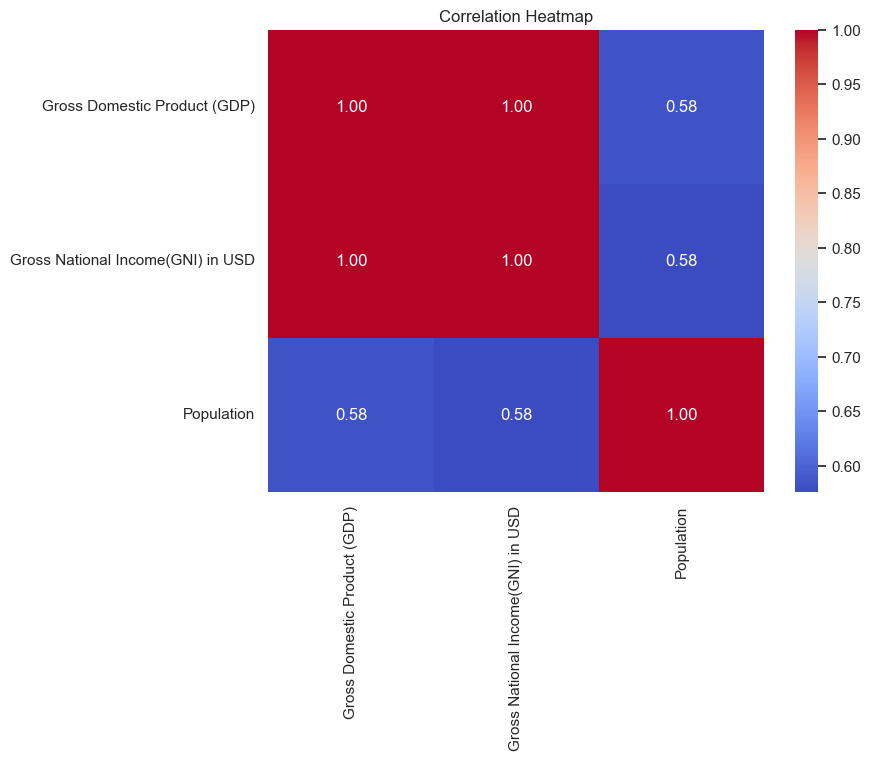

In [13]:

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
